# GARCH Diffusion Model — Demo

This notebook demonstrates the `garch_lnmm` package, which implements Monte Carlo pricing methods for the continuous-time GARCH diffusion model.

We compare:
- Euler-conditional Monte Carlo,
- log-normal moment-matching conditional Monte Carlo,
- Taylor-2 closed-form analytical approximation.

The package is designed to study whether LN-MM can reduce coarse-step discretization bias while preserving variance positivity.

---
## 1. Install and Import Package

This cell ensures the notebook runs in Google Colab or any fresh Python environment.  
If the package is not already installed, it is automatically downloaded from GitHub and installed.  
We then import the required libraries and load `GarchDiffusionMC`, the main class containing our pricing algorithms.

In [ ]:
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

try:
    import garch_lnmm
except ImportError:
    %pip install git+https://github.com/JM357/MATH5030Group11.git --quiet
    import garch_lnmm

In [ ]:
import numpy as np
import scipy.stats as spst
import time
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import norm
import pandas as pd

from garch_lnmm import GarchDiffusionMC

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False})

---
## 2. Mathematical Framework

### 2.1 The GARCH Diffusion SDE
The risk-neutral dynamics of the stock price $S(t)$ and its variance $V(t)$ in the GARCH diffusion model are given by:

$$
dS(t) = r S(t) dt + \sqrt{V(t)} S(t) dW_S(t)
$$
$$
dV(t) = \kappa(\theta - V(t)) dt + \sigma V(t) dW_V(t)
$$

where $dW_S(t)$ and $dW_V(t)$ are Brownian motions with correlation $\rho = 0$ (Barone-Adesi etc., 2003).

### 2.2 The Euler-Maruyama Boundary Problem
The standard Euler discretization for the variance process is:
$$V(t+\Delta t) = V(t) + \kappa(\theta - V(t))\Delta t + \sigma V(t) \sqrt{\Delta t} Z_V$$
where $Z_V \sim N(0,1)$. Because $Z_V$ can be highly negative, $V(t+\Delta t)$ can theoretically cross zero. Standard practice applies an ad-hoc truncation fix: $V(t+\Delta t) = \max(V_{Euler}, 0)$. This introduces a persistent discretization bias that vanishes very slowly as $\Delta t \to 0$.

### 2.3 The Proposed Log-Normal Moment-Matching (LNMM) Scheme
To bypass the zero-boundary violation entirely and allow for large time steps, we assume the conditional distribution of $V(t+\Delta t)$ is Log-Normal. We strictly match the first two analytical moments of the GARCH variance process:
1.  **Conditional Mean:** Let $m_1(u) = E[V(t+u) \mid V(t)] \implies d m_1(u) = \kappa(\theta - m_1(u))du \implies$

    $$M = E[V(t+\Delta t) \mid V(t)] = \theta + (V(t) - \theta)e^{-\kappa \Delta t}$$   <br>
    
    **Conditional Variance:** Let $\Sigma = E[V(t+\Delta t)^2 \mid V(t)] - M^2$, solve and get
    $$\Sigma = \text{Var}(V(t+\Delta t) \mid V(t)) = \frac{\theta^2}{\frac{2\kappa}{\sigma^2} - 1} + e^{-\kappa \Delta t} \frac{2\theta(V(t) - \theta)}{\frac{\kappa}{\sigma^2} - 1} - e^{-2\kappa \Delta t}(V(t) - \theta)^2 + e^{(\sigma^2 - 2\kappa)\Delta t} \left[ V(t)^2 - \frac{2V(t)\theta}{1 - \frac{\sigma^2}{\kappa}} + \frac{\theta^2}{\left(1 - \frac{\sigma^2}{2\kappa}\right)\left(1 - \frac{\sigma^2}{\kappa}\right)} \right]$$

2. **Log-normal distribution:** $\ln(X) \sim \mathcal{N}(m, s^2)$ $$E[X] = \exp\left(m + \frac{s^2}{2}\right)$$
   $$\text{Var}(X) = \exp(2m + s^2) \left[ \exp(s^2) - 1 \right]$$

3. **Moment Matching:**
$$M = \exp\left(m + \frac{s^2}{2}\right)$$
$$\Sigma = \left[ \exp\left(m + \frac{s^2}{2}\right) \right]^2 \left[ \exp(s^2) - 1 \right]$$ <br>
$$\implies s^2 = \ln\left(1 + \frac{\Sigma}{M^2}\right)$$
$$\implies m = \ln(M) - \frac{s^2}{2}$$
The simulated variance becomes strictly positive by design:
$$V(t+\Delta t) = \exp(m + s Z_V)$$

### 2.4 Conditional Monte Carlo & Antithetic Variates
By assuming independence between the stock and variance processes ($\rho = 0$), we employ Conditional Monte Carlo simulation. We simulate only the integrated variance path and feed it directly into the Black-Scholes pricing formula. To further reduce standard error without additional CPU load, we draw $N/2$ random paths and pair them with their antithetic opposites ($-Z_V$).

Conditional on the variance path,
$$
\log S_T
\sim
N\left(
\log S_0
+
rT
-
\frac12 \int_0^T V_t\, dt,
\;
\int_0^T V_t\, dt
\right).
$$

Compare this with the Black--Scholes model:
$$
\log S_T^{BS}
\sim
N\left(
\log S_0
+
\left(r - \frac12 \sigma^2\right)T,
\;
\sigma^2 T
\right).
$$

Matching the variances gives:
$$
\sigma^2 T
=
\int_0^T V_t\, dt.
$$

Therefore, the effective Black--Scholes variance input is
$$
\bar V_T
=
\frac1T \int_0^T V_t\, dt.
$$

We can then put the integrated variance into the BS formula to get the option price. Then average it to get the required benchmark price.


---
## 3. Experimental Setup & Benchmarking
To rigorously test the efficacy of our Lognormal Moment-matching (LNMM) scheme, we benchmark it against both the _fine-step Euler_ discretization method and the _second-order Taylor approximation_ from Barone-Adesi et al. (2003).  

 Experiments are conducted under **two distinct parameter regimes** across varying strike prices $K \in \{70,100,130\}$ and long-dated maturities $T \in \{5,10,15\}$. We establish a high-resolution reference benchmark, or the 'Ground Truth' price, through using the Euler method with an extreme fine discretization (**10,000** time steps) and **one million** Monte Carlo paths to ensure stable convergence and minimal sampling noise.


### 3.1 Fast mean-reverting regime (2003 paper calibration)

Our first experiment follows the parameter regime studied in Barone--Adesi, Rasmussen, and Ravanelli (2003) for long-dated foreign-exchange options. We use

$$
\kappa = 18, \qquad
\theta = \frac{0.16}{18} \approx 0.009, \qquad
\sigma = 1.8,
$$

with $V_0 = \theta$, corresponding to an initial volatility of roughly $9.5\%$.

In [ ]:
# --- EXPERIMENTAL SETUP & BENCHMARKING ---

# Base model parameters
S0 = 100.0          # Initial Asset Price
V0 = 0.009          # Initial Variance
r = 0.05            # Constant risk-free rate
kappa = 18          # Mean-reversion speed of variance
theta = 0.16/kappa  # Long-run mean variance (~0.009)
sigma = 1.8         # Volatility of variance
rho = 0             # Correlation between Brownian Motions driving S_t and V_t

# General K/T cases requested for the simulation.
K_values = [70.0, 100.0, 130.0]
T_values = [5.0, 10.0, 15.0]
# Generate combinatorial K/T test cases
case_grid = pd.MultiIndex.from_product([K_values, T_values], names=["K", "T"]).to_frame(index=False).reset_index(drop=True)
case_grid.insert(0, "Case", range(1, len(case_grid) + 1))

N_paths = 1000000   # one million paths for smooth convergence
ground_truth_steps = 10000
steps_list = [6, 12, 24, 32]
base_seed = 12345

print("--- GARCH Diffusion Numerical Benchmarking ---")
print("K/T simulation cases:")
display(case_grid)


--- GARCH Diffusion Numerical Benchmarking ---
K/T simulation cases:


,Case,K,T
0,1,70.0,5.0
1,2,70.0,10.0
2,3,70.0,15.0
3,4,100.0,5.0
4,5,100.0,10.0
5,6,100.0,15.0
6,7,130.0,5.0
7,8,130.0,10.0
8,9,130.0,15.0


In [ ]:
benchmark_results = []
step_results = []
significance_alpha = 0.05


def significance_against_benchmark(price, benchmark_price, std_error, benchmark_std_error, alpha=0.05):
    combined_se = np.sqrt(std_error**2 + benchmark_std_error**2)

    if combined_se == 0:
        return np.nan, np.nan, False

    z_score = (price - benchmark_price) / combined_se
    p_value = 2.0 * norm.sf(abs(z_score))

    return float(z_score), float(p_value), bool(p_value < alpha)


print("\n--- Error Comparison Across K/T Cases ---")

for _, case in case_grid.iterrows():
    case_id = int(case["Case"])
    K = float(case["K"])
    T = float(case["T"])
    seed = base_seed + case_id - 1

    model = GarchDiffusionMC(S0, V0, r, kappa, theta, sigma, rho, T)

    print(f"\nCase {case_id}: K={K:.0f}, T={T:.0f}")
    print(f"Computing 'Ground Truth' with Euler, N_steps={ground_truth_steps}...")

    start_time = time.time()
    true_stats = model.simulate_euler_cond_mc(
        N_paths=N_paths,
        N_steps=ground_truth_steps,
        K=K,
        seed=seed,
        return_stats=True
    )
    time_true = time.time() - start_time
    price_true = true_stats["price"]
    std_true = true_stats["std_dev"]
    se_true = true_stats["std_error"]

    # --- Taylor-2 Baseline ---
    start_time = time.time()
    price_taylor = model.garch_taylor2_call(K=K)
    time_taylor = time.time() - start_time
    error_taylor = abs(price_taylor - price_true)
    z_taylor, p_taylor, sig_taylor = significance_against_benchmark(
        price_taylor,
        price_true,
        0.0,
        se_true,
        alpha=significance_alpha
    )

    benchmark_results.append({
        "Case": case_id,
        "K": K,
        "T": T,
        "Fine-Euler Price": price_true,
        "Fine-Euler Std Dev": std_true,
        "Fine-Euler Std Error": se_true,
        "Taylor-2 Price": price_taylor,
        "Taylor-2 Error": error_taylor,
        "Taylor-2 z": z_taylor,
        "Taylor-2 p-value": p_taylor,
        "Taylor-2 Significant (5%)": sig_taylor,
        "Fine-Euler Steps": ground_truth_steps,
        "Fine-Euler Time": time_true,
        "Taylor-2 Time": time_taylor
    })

    print(
        f"Fine-step Euler Price: {price_true:.4f} "
        f"(Std Dev={std_true:.6f}, Std Err={se_true:.6f}, Took {time_true:.2f} seconds)"
    )
    print(
        f"Taylor-2 Price: {price_taylor:.4f}, Err={error_taylor:.6f}, "
        f"z={z_taylor:.2f}, p={p_taylor:.3g}, Significant={sig_taylor} "
        f"(Took {time_taylor:.2f} seconds)"
    )

    for steps in steps_list:
        start_time = time.time()
        euler_stats = model.simulate_euler_cond_mc(
            N_paths=N_paths,
            N_steps=steps,
            K=K,
            seed=seed,
            return_stats=True
        )
        time_euler = time.time() - start_time
        price_euler = euler_stats["price"]
        std_euler = euler_stats["std_dev"]
        se_euler = euler_stats["std_error"]
        error_euler = abs(price_euler - price_true)
        z_euler, p_euler, sig_euler = significance_against_benchmark(
            price_euler,
            price_true,
            se_euler,
            se_true,
            alpha=significance_alpha
        )

        start_time = time.time()
        mm_stats = model.simulate_moment_matching_cond_mc(
            N_paths=N_paths,
            N_steps=steps,
            K=K,
            seed=seed,
            return_stats=True
        )
        time_mm = time.time() - start_time
        price_mm = mm_stats["price"]
        std_mm = mm_stats["std_dev"]
        se_mm = mm_stats["std_error"]
        error_mm = abs(price_mm - price_true)
        z_mm, p_mm, sig_mm = significance_against_benchmark(
            price_mm,
            price_true,
            se_mm,
            se_true,
            alpha=significance_alpha
        )

        step_results.append({
            "Case": case_id,
            "K": K,
            "T": T,
            "Steps": steps,
            "Euler Price": price_euler,
            "Euler Std Dev": std_euler,
            "Euler Std Error": se_euler,
            "Euler Error": error_euler,
            "Euler z": z_euler,
            "Euler p-value": p_euler,
            "Euler Significant (5%)": sig_euler,
            "Euler Time": time_euler,
            "LN-MM Price": price_mm,
            "LN-MM Std Dev": std_mm,
            "LN-MM Std Error": se_mm,
            "LN-MM Error": error_mm,
            "LN-MM z": z_mm,
            "LN-MM p-value": p_mm,
            "LN-MM Significant (5%)": sig_mm,
            "LN-MM Time": time_mm,
            "Taylor-2 Price": price_taylor,
            "Taylor-2 Error": error_taylor,
            "Taylor-2 z": z_taylor,
            "Taylor-2 p-value": p_taylor,
            "Taylor-2 Significant (5%)": sig_taylor,
            "Taylor-2 Time": time_taylor,
        })

        print(
            f"Steps={steps:3d} | "
            f"Euler Price={price_euler:.4f}, SD={std_euler:.6f}, SE={se_euler:.6f}, "
            f"Err={error_euler:.6f}, p={p_euler:.3g}, Sig={sig_euler} | "
            f"LN-MM Price={price_mm:.4f}, SD={std_mm:.6f}, SE={se_mm:.6f}, "
            f"Err={error_mm:.6f}, p={p_mm:.3g}, Sig={sig_mm} | "
            f"Taylor-2 Err={error_taylor:.6f}, p={p_taylor:.3g}, Sig={sig_taylor}"
        )

benchmark_df = pd.DataFrame(benchmark_results)
results_df = pd.DataFrame(step_results)

#print("\nGround Truth Results:")
#display(benchmark_df)

#print("\nDetailed Step Results:")
#display(results_df)



--- Error Comparison Across K/T Cases ---

Case 1: K=70, T=5
Computing 'Ground Truth' with Euler, N_steps=10000...
Fine-step Euler Price: 45.4932 (Std Dev=0.002374, Std Err=0.000002, Took 72.18 seconds)
Taylor-2 Price: 45.4932, Err=0.000001, z=-0.27, p=0.789, Significant=False (Took 0.00 seconds)
Steps=  6 | Euler Price=47.4819, SD=0.355294, SE=0.000355, Err=1.988656, p=0, Sig=True | LN-MM Price=45.4944, SD=0.006964, SE=0.000007, Err=0.001154, p=0, Sig=True | Taylor-2 Err=0.000001, p=0.789, Sig=False
Steps= 12 | Euler Price=46.1674, SD=0.069006, SE=0.000069, Err=0.674157, p=0, Sig=True | LN-MM Price=45.4937, SD=0.004719, SE=0.000005, Err=0.000519, p=0, Sig=True | Taylor-2 Err=0.000001, p=0.789, Sig=False
Steps= 24 | Euler Price=45.5995, SD=0.009499, SE=0.000009, Err=0.106334, p=0, Sig=True | LN-MM Price=45.4934, SD=0.003335, SE=0.000003, Err=0.000188, p=0, Sig=True | Taylor-2 Err=0.000001, p=0.789, Sig=False
Steps= 32 | Euler Price=45.5253, SD=0.004962, SE=0.000005, Err=0.032105, p=0,

#### 3.1.1 Table for Runtime Comparison

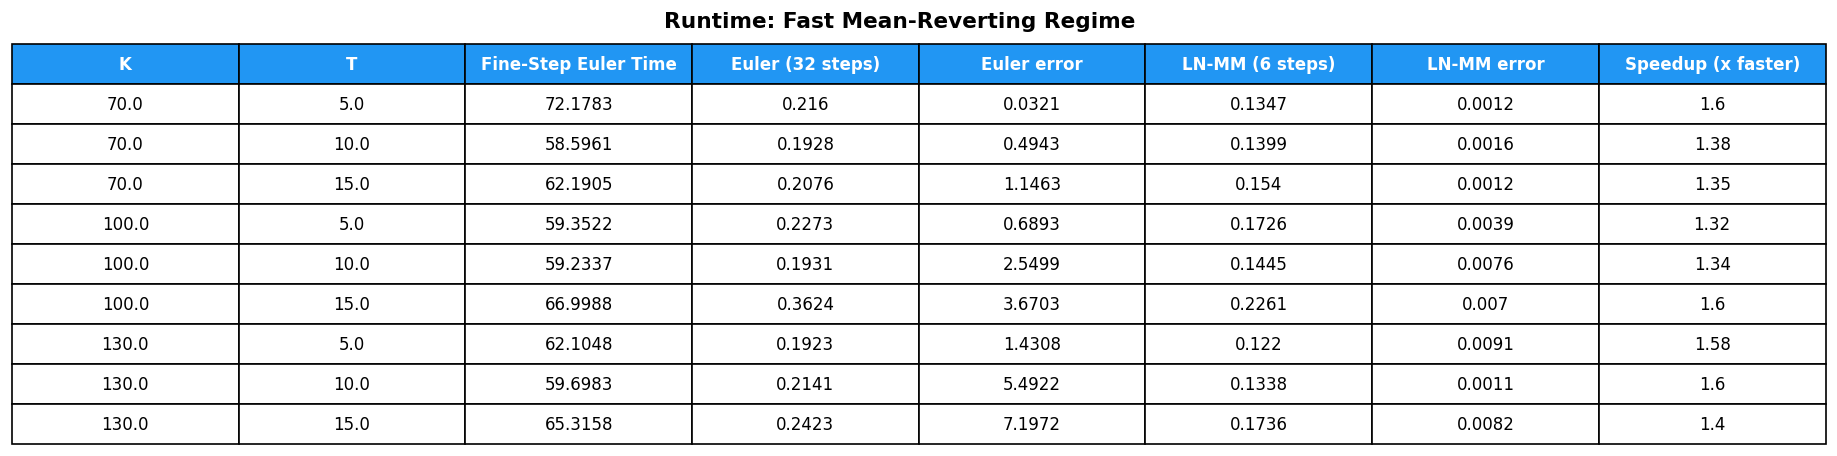

In [ ]:
df2 = results_df.copy()
benchmark2 = benchmark_df.copy()

# Runtime comparison table: Euler (32 steps) vs LNMM (6 steps)

euler_32 = df2[df2.iloc[:, 3] == 32].iloc[:, [1, 2, 11, 7]].copy()
euler_32.columns = ["K", "T", "Euler (32 steps)", "Euler error"]

lnmm_6 = df2[df2.iloc[:, 3] == 6].iloc[:, [1, 2, 19, 15]].copy()
lnmm_6.columns = ["K", "T", "LN-MM (6 steps)", "LN-MM error"]

# Fine-step Euler runtime from benchmark_df
fine_runtime = benchmark2[["K", "T", "Fine-Euler Time"]].copy()
fine_runtime.columns = ["K", "T", "Fine-Step Euler Time"]

# Merge runtime tables
runtime = (
    euler_32
    .merge(fine_runtime, on=["K", "T"])
    .merge(lnmm_6, on=["K", "T"])
    .sort_values(["K", "T"])
)

runtime["Speedup (x faster)"] = (
    runtime["Euler (32 steps)"] / runtime["LN-MM (6 steps)"]
).round(2)

runtime = runtime[
    [
        "K",
        "T",
        "Fine-Step Euler Time",
        "Euler (32 steps)",
        "Euler error",
        "LN-MM (6 steps)",
        "LN-MM error",
        "Speedup (x faster)",
    ]
]

fig2, ax2 = plt.subplots(figsize=(13, 4))
ax2.axis("off")
table = ax2.table(
    cellText=runtime.round(4).values,
    colLabels=runtime.columns,
    cellLoc="center",
    loc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.5, 2.0)

# Header row styling
for j in range(len(runtime.columns)):
    table[0, j].set_facecolor("#2196F3")
    table[0, j].set_text_props(color="white", fontweight="bold")

fig2.suptitle("Runtime: Fast Mean-Reverting Regime", fontsize=13, fontweight="bold")
plt.savefig("runtime_table_fast.png", dpi=150, bbox_inches="tight")
plt.show()

#### 3.1.2 Heat Map for Visualization of Error

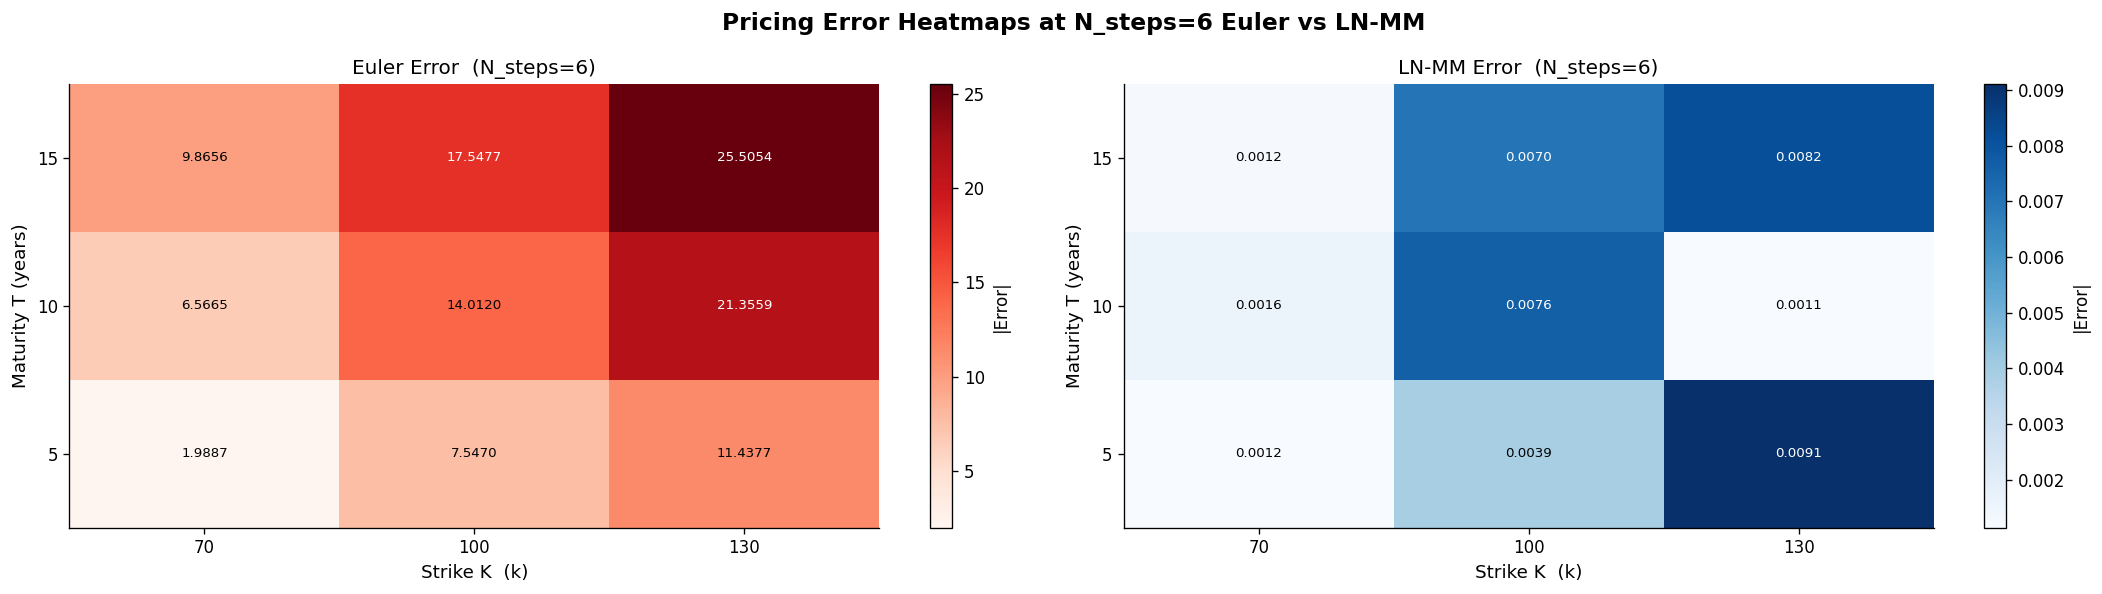

Saved → heatmap_errors.png


In [ ]:
# Use only 6-step rows (worst case for Euler, best case comparison)
N_STEPS = 6

df = df2[df2.iloc[:, 3] == N_STEPS].iloc[:, [1, 2, 7, 15, 21]].copy()
df.columns = ["k", "T", "Euler_Error", "LNMM_Error", "Taylor_Error"]

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce").abs()

df = df.dropna()
df["k"] = df["k"].astype(int)
df["T"] = df["T"].astype(int)

# ── 2. Pivot each error into (T x k) grid ────────────────────────────────────────
def make_pivot(df, col):
    return df.pivot(index="T", columns="k", values=col).sort_index(ascending=False)

euler_pivot  = make_pivot(df, "Euler_Error")
lnmm_pivot   = make_pivot(df, "LNMM_Error")
taylor_pivot = make_pivot(df, "Taylor_Error")

# ── 3. Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Pricing Error Heatmaps at N_steps={N_STEPS} Euler vs LN-MM",
             fontsize=14, fontweight="bold")

configs = [
    (euler_pivot,  "Reds",   "Euler Error"),
    (lnmm_pivot,   "Blues",  "LN-MM Error"),
     (taylor_pivot, "Purples","Taylor-2 Error")
]

for ax, (pivot, cmap, title) in zip(axes, configs):
    vals = pivot.values.astype(float)
    im = ax.imshow(vals, cmap=cmap, aspect="auto")
    plt.colorbar(im, ax=ax, label="|Error|")

    # Annotate each cell
    for i in range(vals.shape[0]):
        for j in range(vals.shape[1]):
            v = vals[i, j]
            txt = f"{v:.4f}" if v >= 0.001 else f"{v:.4e}"
            # pick text color based on background brightness
            normed = (v - vals.min()) / (vals.max() - vals.min() + 1e-12)
            text_color = "white" if normed > 0.6 else "black"
            ax.text(j, i, txt, ha="center", va="center",
                    fontsize=8, color=text_color)

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel("Strike K  (k)", fontsize=11)
    ax.set_ylabel("Maturity T (years)", fontsize=11)
    ax.set_title(f"{title}  (N_steps={N_STEPS})", fontsize=12)

plt.tight_layout()
plt.savefig("heatmap_errors.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → heatmap_errors.png")

###  3.2 Andersen-inspired slow mean-reverting long-dated FX regime
We initialize the variance far above its long-run mean, setting $V_0 = 0.09$ while $\theta = 0.04$. This corresponds to an initial volatility of $30\%$, compared with a long-run volatility of $20\%$. We also reduce the mean-reversion speed to $\kappa = 0.75$, so the variance process reverts slowly toward its long-run mean. The volatility-of-variance parameter is set to $\sigma = 0.85$, leaving the process stochastic while still satisfying the stationarity condition $2\kappa > \sigma^2$.

This second regime is inspired by Andersen’s long-dated FX test case, where the variance process has slow mean reversion and starts at its long-run level. This is also consistent with the motivation of Barone-Adesi, Rasmussen, and Ravanelli (2003), who emphasize the uncorrelated GARCH diffusion model as particularly relevant for foreign-exchange options, where volatility smiles are often relatively symmetric.

In [ ]:
# --- EXPERIMENTAL SETUP & BENCHMARKING ---

# Base model parameters
S0 = 100.0      # Initial Asset Price
V0 = 0.09       # Initial Variance
r = 0.05        # Constant risk-free rate
kappa = 0.75    # Mean-reversion speed of variance
theta = 0.04    # Long-run mean variance (~0.009)
sigma = 0.85    # Volatility of variance
rho = 0         # Correlation between Brownian Motions driving S_t and V_t

# General K/T cases requested for the simulation.
K_values = [70.0, 100.0, 130.0]
T_values = [5.0, 10.0, 15.0]
# Generate combinatorial K/T test cases
case_grid = pd.MultiIndex.from_product([K_values, T_values], names=["K", "T"]).to_frame(index=False).reset_index(drop=True)
case_grid.insert(0, "Case", range(1, len(case_grid) + 1))

N_paths = 1000000  # 1 million paths for smooth convergence
ground_truth_steps = 10000
steps_list = [6, 12, 24, 32]
base_seed = 12345

print("--- GARCH Diffusion Numerical Benchmarking ---")
print("K/T simulation cases:")
display(case_grid)


--- GARCH Diffusion Numerical Benchmarking ---
K/T simulation cases:


,Case,K,T
0,1,70.0,5.0
1,2,70.0,10.0
2,3,70.0,15.0
3,4,100.0,5.0
4,5,100.0,10.0
5,6,100.0,15.0
6,7,130.0,5.0
7,8,130.0,10.0
8,9,130.0,15.0


In [ ]:
benchmark_results = []
step_results = []
significance_alpha = 0.05


def significance_against_benchmark(price, benchmark_price, std_error, benchmark_std_error, alpha=0.05):
    combined_se = np.sqrt(std_error**2 + benchmark_std_error**2)

    if combined_se == 0:
        return np.nan, np.nan, False

    z_score = (price - benchmark_price) / combined_se
    p_value = 2.0 * norm.sf(abs(z_score))

    return float(z_score), float(p_value), bool(p_value < alpha)


print("\n--- Error Comparison Across K/T Cases ---")

for _, case in case_grid.iterrows():
    case_id = int(case["Case"])
    K = float(case["K"])
    T = float(case["T"])
    seed = base_seed + case_id - 1

    model = GarchDiffusionMC(S0, V0, r, kappa, theta, sigma, rho, T)

    print(f"\nCase {case_id}: K={K:.0f}, T={T:.0f}")
    print(f"Computing 'Ground Truth' with Euler, N_steps={ground_truth_steps}...")

    start_time = time.time()
    true_stats = model.simulate_euler_cond_mc(
        N_paths=N_paths,
        N_steps=ground_truth_steps,
        K=K,
        seed=seed,
        return_stats=True
    )
    time_true = time.time() - start_time
    price_true = true_stats["price"]
    std_true = true_stats["std_dev"]
    se_true = true_stats["std_error"]

    # --- Taylor-2 Baseline ---
    start_time = time.time()
    price_taylor = model.garch_taylor2_call(K=K)
    time_taylor = time.time() - start_time
    error_taylor = abs(price_taylor - price_true)
    z_taylor, p_taylor, sig_taylor = significance_against_benchmark(
        price_taylor,
        price_true,
        0.0,
        se_true,
        alpha=significance_alpha
    )

    benchmark_results.append({
        "Case": case_id,
        "K": K,
        "T": T,
        "Fine-Euler Price": price_true,
        "Fine-Euler Std Dev": std_true,
        "Fine-Euler Std Error": se_true,
        "Taylor-2 Price": price_taylor,
        "Taylor-2 Error": error_taylor,
        "Taylor-2 z": z_taylor,
        "Taylor-2 p-value": p_taylor,
        "Taylor-2 Significant (5%)": sig_taylor,
        "Fine-Euler Steps": ground_truth_steps,
        "Fine-Euler Time": time_true,
        "Taylor-2 Time": time_taylor
    })

    print(
        f"Fine-step Euler Price: {price_true:.4f} "
        f"(Std Dev={std_true:.6f}, Std Err={se_true:.6f}, Took {time_true:.2f} seconds)"
    )
    print(
        f"Taylor-2 Price: {price_taylor:.4f}, Err={error_taylor:.6f}, "
        f"z={z_taylor:.2f}, p={p_taylor:.3g}, Significant={sig_taylor} "
        f"(Took {time_taylor:.2f} seconds)"
    )

    for steps in steps_list:
        start_time = time.time()
        euler_stats = model.simulate_euler_cond_mc(
            N_paths=N_paths,
            N_steps=steps,
            K=K,
            seed=seed,
            return_stats=True
        )
        time_euler = time.time() - start_time
        price_euler = euler_stats["price"]
        std_euler = euler_stats["std_dev"]
        se_euler = euler_stats["std_error"]
        error_euler = abs(price_euler - price_true)
        z_euler, p_euler, sig_euler = significance_against_benchmark(
            price_euler,
            price_true,
            se_euler,
            se_true,
            alpha=significance_alpha
        )

        start_time = time.time()
        mm_stats = model.simulate_moment_matching_cond_mc(
            N_paths=N_paths,
            N_steps=steps,
            K=K,
            seed=seed,
            return_stats=True
        )
        time_mm = time.time() - start_time
        price_mm = mm_stats["price"]
        std_mm = mm_stats["std_dev"]
        se_mm = mm_stats["std_error"]
        error_mm = abs(price_mm - price_true)
        z_mm, p_mm, sig_mm = significance_against_benchmark(
            price_mm,
            price_true,
            se_mm,
            se_true,
            alpha=significance_alpha
        )

        step_results.append({
            "Case": case_id,
            "K": K,
            "T": T,
            "Steps": steps,
            "Euler Price": price_euler,
            "Euler Std Dev": std_euler,
            "Euler Std Error": se_euler,
            "Euler Error": error_euler,
            "Euler z": z_euler,
            "Euler p-value": p_euler,
            "Euler Significant (5%)": sig_euler,
            "Euler Time": time_euler,
            "LN-MM Price": price_mm,
            "LN-MM Std Dev": std_mm,
            "LN-MM Std Error": se_mm,
            "LN-MM Error": error_mm,
            "LN-MM z": z_mm,
            "LN-MM p-value": p_mm,
            "LN-MM Significant (5%)": sig_mm,
            "LN-MM Time": time_mm,
            "Taylor-2 Price": price_taylor,
            "Taylor-2 Error": error_taylor,
            "Taylor-2 z": z_taylor,
            "Taylor-2 p-value": p_taylor,
            "Taylor-2 Significant (5%)": sig_taylor,
            "Taylor-2 Time": time_taylor,
        })

        print(
            f"Steps={steps:3d} | "
            f"Euler Price={price_euler:.4f}, SD={std_euler:.6f}, SE={se_euler:.6f}, "
            f"Err={error_euler:.6f}, p={p_euler:.3g}, Sig={sig_euler} | "
            f"LN-MM Price={price_mm:.4f}, SD={std_mm:.6f}, SE={se_mm:.6f}, "
            f"Err={error_mm:.6f}, p={p_mm:.3g}, Sig={sig_mm} | "
            f"Taylor-2 Err={error_taylor:.6f}, p={p_taylor:.3g}, Sig={sig_taylor}"
        )

benchmark_df = pd.DataFrame(benchmark_results)
results_df = pd.DataFrame(step_results)

#print("\nGround Truth Results:")
#display(benchmark_df)

#print("\nDetailed Step Results:")
#display(results_df)



--- Error Comparison Across K/T Cases ---

Case 1: K=70, T=5
Computing 'Ground Truth' with Euler, N_steps=10000...
Fine-step Euler Price: 47.6821 (Std Dev=1.879533, Std Err=0.001880, Took 69.66 seconds)
Taylor-2 Price: 47.7619, Err=0.079827, z=42.47, p=0, Significant=True (Took 0.00 seconds)
Steps=  6 | Euler Price=47.8751, SD=2.207657, SE=0.002208, Err=0.193042, p=0, Sig=True | LN-MM Price=47.7107, SD=1.884330, SE=0.001884, Err=0.028606, p=6.04e-27, Sig=True | Taylor-2 Err=0.079827, p=0, Sig=True
Steps= 12 | Euler Price=47.6994, SD=2.063054, SE=0.002063, Err=0.017299, p=5.7e-10, Sig=True | LN-MM Price=47.6891, SD=1.873265, SE=0.001873, Err=0.006991, p=0.00843, Sig=True | Taylor-2 Err=0.079827, p=0, Sig=True
Steps= 24 | Euler Price=47.6426, SD=1.967169, SE=0.001967, Err=0.039464, p=1.13e-47, Sig=True | LN-MM Price=47.6832, SD=1.870406, SE=0.001870, Err=0.001113, p=0.675, Sig=False | Taylor-2 Err=0.079827, p=0, Sig=True
Steps= 32 | Euler Price=47.6442, SD=1.944460, SE=0.001944, Err=0.0

#### 3.2.1 Line Graph for Error Convergence

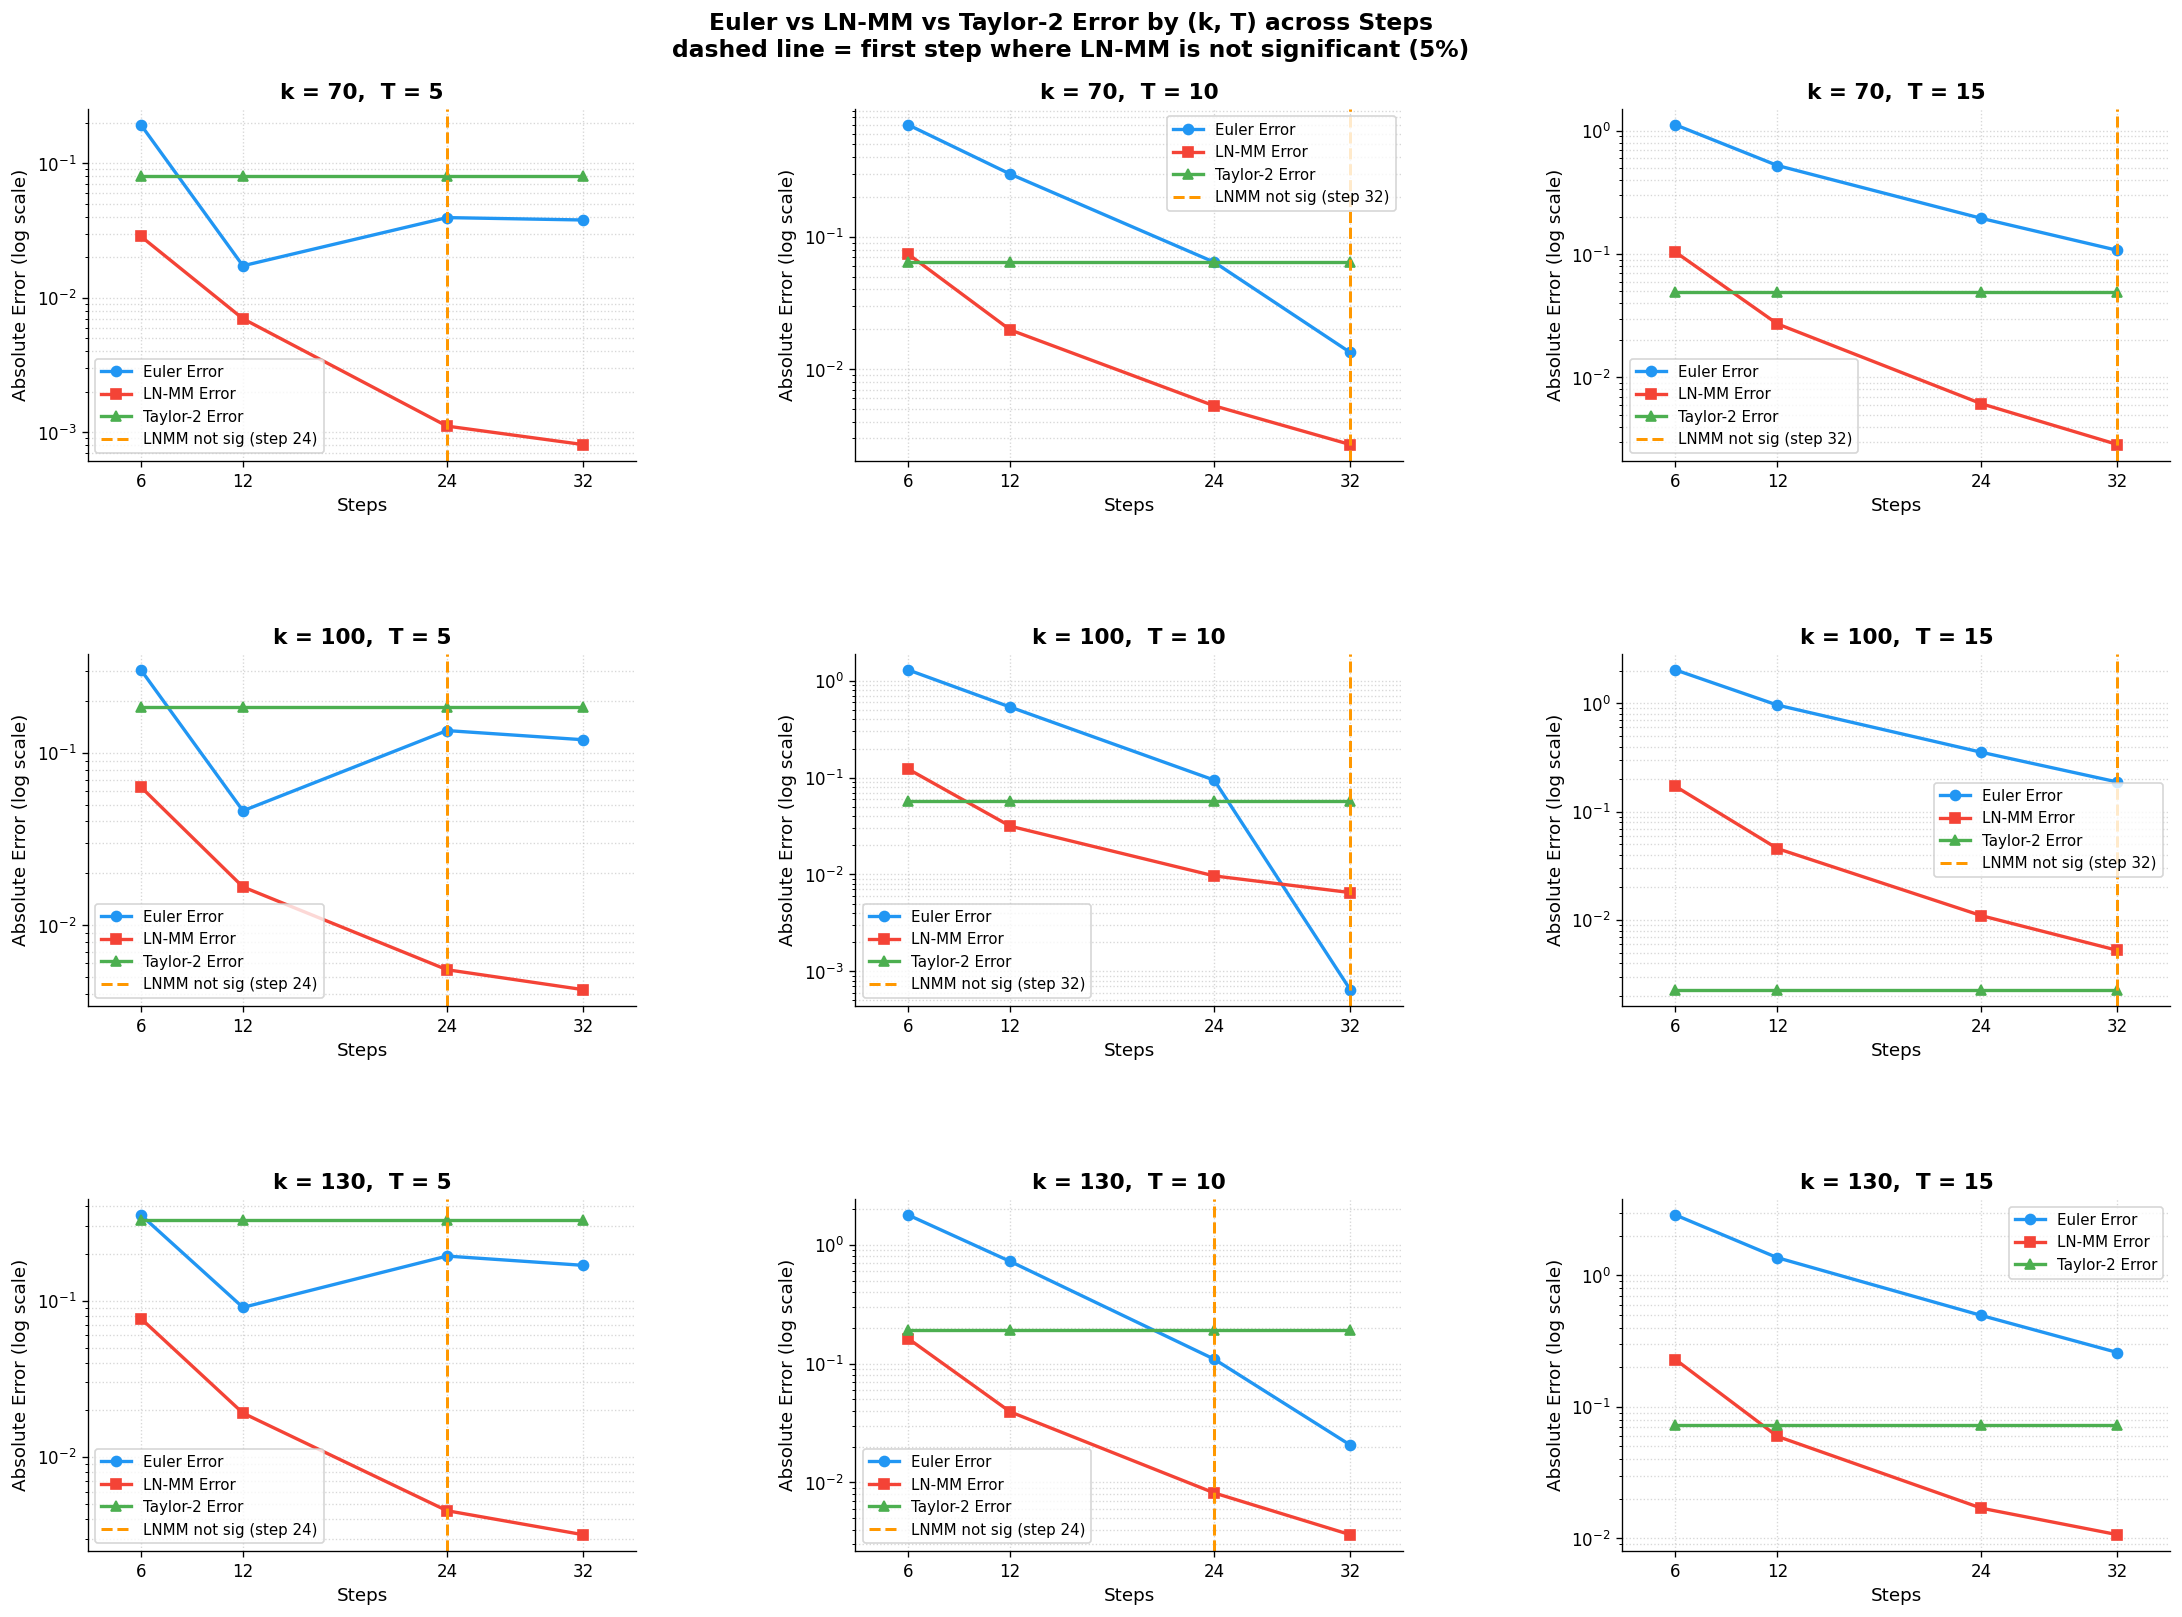

Saved → error_comparison.png


In [ ]:
df_raw = results_df.copy()
benchmark1 = benchmark_df.copy()

df = df_raw.iloc[:, [1, 2, 3, 7, 10, 15, 18, 21]].copy()
df.columns = ["k", "T", "Steps", "Euler_Error", "Euler_Sig", "LNMM_Error", "LNMM_Sig", "Taylor_Error"]

# ── 2. Clean & coerce ────────────────────────────────────────────────────────────
for col in ["k", "T", "Steps"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["k", "T", "Steps"])

df["k"]     = df["k"].astype(int)
df["T"]     = df["T"].astype(int)
df["Steps"] = df["Steps"].astype(int)

df["Euler_Error"]  = pd.to_numeric(df["Euler_Error"],  errors="coerce").abs()
df["LNMM_Error"]   = pd.to_numeric(df["LNMM_Error"],   errors="coerce").abs()
df["Taylor_Error"] = pd.to_numeric(df["Taylor_Error"], errors="coerce").abs()

def to_bool(col):
    return col.astype(str).str.strip().str.upper().map({"TRUE": True, "FALSE": False})

df["Euler_Sig"] = to_bool(df["Euler_Sig"])
df["LNMM_Sig"]  = to_bool(df["LNMM_Sig"])

# ── 3. Plot ──────────────────────────────────────────────────────────────────────
combos = df[["k", "T"]].drop_duplicates().sort_values(["k", "T"]).values.tolist()
ncols  = 3
nrows  = int(np.ceil(len(combos) / ncols))

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(6.5 * ncols, 4.5 * nrows))
fig.subplots_adjust(top=0.95, hspace=0.55, wspace=0.4,
                    left=0.08, right=0.97, bottom=0.06)
axes = np.array(axes).flatten()

EULER_COLOR  = "#2196F3"
LNMM_COLOR   = "#F44336"
TAYLOR_COLOR = "#4CAF50"
VLINE_COLOR  = "#FF9800"

for ax, (k_val, T_val) in zip(axes, combos):
    sub = df[(df["k"] == k_val) & (df["T"] == T_val)].sort_values("Steps")
    if sub.empty:
        ax.set_visible(False)
        continue

    steps = sub["Steps"].values

    ax.plot(steps, sub["Euler_Error"].values,
            marker="o", color=EULER_COLOR,  linewidth=2, label="Euler Error")
    ax.plot(steps, sub["LNMM_Error"].values,
            marker="s", color=LNMM_COLOR,   linewidth=2, label="LN-MM Error")
    ax.plot(steps, sub["Taylor_Error"].values,
            marker="^", color=TAYLOR_COLOR, linewidth=2, label="Taylor-2 Error")

    not_sig = sub[sub["LNMM_Sig"] == False]
    if not not_sig.empty:
        first_not_sig_step = not_sig["Steps"].iloc[0]
        ax.axvline(x=first_not_sig_step, color=VLINE_COLOR,
                   linestyle="--", linewidth=1.8,
                   label=f"LNMM not sig (step {first_not_sig_step})")

    step_range = steps[-1] - steps[0]
    ax.set_xlim(steps[0] - step_range * 0.12, steps[-1] + step_range * 0.12)

    ax.set_yscale("log")
    ax.set_xticks(steps)
    ax.set_xlabel("Steps", fontsize=11)
    ax.set_ylabel("Absolute Error (log scale)", fontsize=11)
    ax.set_title(f"k = {k_val},  T = {T_val}", fontsize=13, fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(True, which="both", linestyle=":", alpha=0.5)

for ax in axes[len(combos):]:
    ax.set_visible(False)

fig.suptitle("Euler vs LN-MM vs Taylor-2 Error by (k, T) across Steps\n"
             "dashed line = first step where LN-MM is not significant (5%)",
             fontsize=14, fontweight="bold", y=1.01)

plt.savefig("error_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → error_comparison.png")


#### 3.2.2 Table for Runtime Comparison

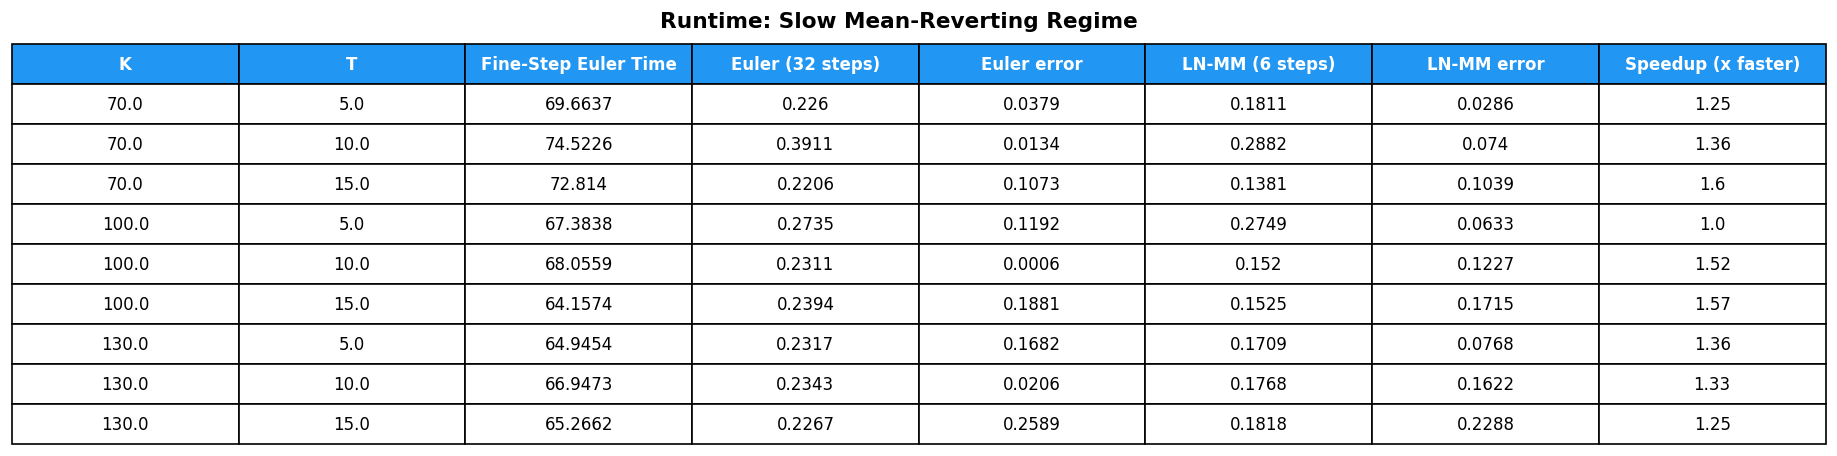

In [ ]:
df = df_raw.copy()


# — Runtime comparison table: Euler (32 steps) vs LNMM (6 steps) ————————

euler_32 = df[df.iloc[:, 3] == 32].iloc[:, [1, 2, 11, 7]].copy()
euler_32.columns = ["K", "T", "Euler (32 steps)", "Euler error"]

lnmm_6 = df[df.iloc[:, 3] == 6].iloc[:, [1, 2, 19, 15]].copy()
lnmm_6.columns = ["K", "T", "LN-MM (6 steps)", "LN-MM error"]

# Fine-step Euler runtime from benchmark_df
fine_runtime = benchmark1[["K", "T", "Fine-Euler Time"]].copy()
fine_runtime.columns = ["K", "T", "Fine-Step Euler Time"]

# Merge runtime tables
runtime = (
    euler_32
    .merge(fine_runtime, on=["K", "T"])
    .merge(lnmm_6, on=["K", "T"])
    .sort_values(["K", "T"])
)

runtime["Speedup (x faster)"] = (
    runtime["Euler (32 steps)"] / runtime["LN-MM (6 steps)"]
).round(2)

runtime = runtime[
    [
        "K",
        "T",
        "Fine-Step Euler Time",
        "Euler (32 steps)",
        "Euler error",
        "LN-MM (6 steps)",
        "LN-MM error",
        "Speedup (x faster)",
    ]
]

fig2, ax2 = plt.subplots(figsize=(13, 4))
ax2.axis("off")
table = ax2.table(
    cellText=runtime.round(4).values,
    colLabels=runtime.columns,
    cellLoc="center",
    loc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.5, 2.0)

# Header row styling
for j in range(len(runtime.columns)):
    table[0, j].set_facecolor("#2196F3")
    table[0, j].set_text_props(color="white", fontweight="bold")

fig2.suptitle("Runtime: Slow Mean-Reverting Regime", fontsize=13, fontweight="bold")
plt.savefig("runtime_table_slow.png", dpi=150, bbox_inches="tight")
plt.show()